Dhanush Sambasivam ( 121331816 )

Madhumitha Rajagopal ( 121331472 )

## Part 1: Data Loading

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from tabulate import tabulate

def load_spy_data():
    """
    Load 10 years of SPY data from Yahoo Finance.
    Returns:
        DataFrame with daily columns: ['Open', 'High', 'Low', 'Close', 'Volume']
    """
    spy = yf.Ticker("SPY")
    df = spy.history(period="10y", interval="1d")
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    df.dropna(inplace=True)
    df.columns = df.columns.str.lower()
    return df

# Run this to verify
raw_data = load_spy_data()
print("Sample SPY Data (10y):")
display(raw_data.head())

Sample SPY Data (10y):


,open,high,low,close,volume
Date,,,,,
2015-05-04 00:00:00-04:00,177.723324,178.388016,177.613954,177.799057,70927200
2015-05-05 00:00:00-04:00,177.555069,177.916867,175.619907,175.762939,113326200
2015-05-06 00:00:00-04:00,176.318213,176.629517,173.962365,175.039322,135060200
2015-05-07 00:00:00-04:00,174.938399,176.166810,174.601855,175.737701,88244900
2015-05-08 00:00:00-04:00,177.428829,178.253372,177.344687,178.051437,155877300


## Part 2: Feature Engineering

In [ ]:
def preprocess_data(df):
    """
    Takes in raw SPY data and creates discrete observation columns
    like Return_Bin, Vol_Bin, and RSI_Signal.
    Parameters:
    df : pd.DataFrame - with at least a 'close' column
    Returns:
    df : pd.DataFrame - with added features for HMM
    """

    # Step 1 - Calculate daily returns (in %)
    df['Return'] = df['close'].pct_change() * 100

    # Step 2 - Compute 5-day rolling volatility (annualized)
    daily_std = df['Return'].rolling(5).std()
    df['Volatility'] = daily_std * (252 ** 0.5)

    # Step 3 - RSI calculation with 14-day window
    def compute_rsi(series, window=14):
        change = series.diff()
        up = change.clip(lower=0)
        down = -1 * change.clip(upper=0)

        avg_gain = up.rolling(window).mean()
        avg_loss = down.rolling(window).mean()

        rs = avg_gain / avg_loss
        rsi = 100 - (100 / (1 + rs))
        return rsi

    df['RSI'] = compute_rsi(df['close'])

    # Step 4 - Convert features into discrete categories

    # Return binning: Tertiles
    df['Return_Bin'] = pd.qcut(df['Return'], 3, labels=['Low', 'Medium', 'High'])

    # Volatility binning: High if above median
    median_vol = df['Volatility'].median()
    df['Vol_Bin'] = df['Volatility'].apply(lambda v: 'High' if v > median_vol else 'Low')

    # RSI Signal: Overbought, Oversold, or Neutral
    def rsi_category(value):
        if value > 70:
            return 'Overbought'
        elif value < 30:
            return 'Oversold'
        else:
            return 'Neutral'

    df['RSI_Signal'] = df['RSI'].apply(rsi_category)

    return df.dropna()

# Run on a copy to avoid modifying original data
processed_data = preprocess_data(raw_data.copy())

# Preview final processed features
processed_data[['Return', 'Volatility', 'Return_Bin', 'Vol_Bin', 'RSI_Signal']].tail()


,Return,Volatility,Return_Bin,Vol_Bin,RSI_Signal
Date,,,,,
2025-04-28 00:00:00-04:00,0.038130,16.415142,Medium,High,Neutral
2025-04-29 00:00:00-04:00,0.629941,12.948942,High,High,Neutral
2025-04-30 00:00:00-04:00,0.039683,13.406639,Medium,High,Neutral
2025-05-01 00:00:00-04:00,0.708694,5.663369,High,Low,Neutral
2025-05-02 00:00:00-04:00,1.484420,9.466974,High,Low,Neutral


## Part 3: HMM Parameters

In [ ]:
from tabulate import tabulate

# HMM Market Regimes
states = ['Bull', 'Bear', 'Sideways']

# Manually set transition probabilities between regimes
# Constraint: No direct transitions between Bull and Bear
transition_prob = {
    'Bull': {
        'Bull': 0.7,
        'Sideways': 0.3,
        'Bear': 0.0
    },
    'Sideways': {
        'Bull': 0.3,
        'Sideways': 0.4,
        'Bear': 0.3
    },
    'Bear': {
        'Bull': 0.0,
        'Sideways': 0.4,
        'Bear': 0.6
    }
}

# Emission probabilities for each observation type
# Based on typical technical indicator behavior during each regime
emission_prob = {
    'Bull': {
        'Return_Bin': {'Low': 0.1, 'Medium': 0.3, 'High': 0.6},
        'Vol_Bin': {'Low': 0.7, 'High': 0.3},
        'RSI_Signal': {'Overbought': 0.5, 'Neutral': 0.4, 'Oversold': 0.1}
    },
    'Bear': {
        'Return_Bin': {'Low': 0.6, 'Medium': 0.3, 'High': 0.1},
        'Vol_Bin': {'Low': 0.2, 'High': 0.8},
        'RSI_Signal': {'Overbought': 0.1, 'Neutral': 0.3, 'Oversold': 0.6}
    },
    'Sideways': {
        'Return_Bin': {'Low': 0.3, 'Medium': 0.4, 'High': 0.3},
        'Vol_Bin': {'Low': 0.5, 'High': 0.5},
        'RSI_Signal': {'Overbought': 0.2, 'Neutral': 0.6, 'Oversold': 0.2}
    }
}

# Print transition matrix in tabular format
print("Transition Matrix:")
transition_table = []
for current_state in states:
    row = [current_state] + [transition_prob[current_state][next_state] for next_state in states]
    transition_table.append(row)

print(tabulate(transition_table, headers=["From"] + states))

Transition Matrix:
From        Bull    Bear    Sideways
--------  ------  ------  ----------
Bull         0.7     0           0.3
Bear         0       0.6         0.4
Sideways     0.3     0.3         0.4


## Part 4: Constrained Viterbi Implementation

In [ ]:
def constrained_viterbi(obs_seq, states, trans_prob, emit_prob, min_days=5):
    """
    Custom Viterbi algorithm with constraints:
    - No direct Bull → Bear transitions
    - Enforce minimum regime persistence of 5 days
    """
    T = len(obs_seq)
    V = [{} for _ in range(T)]
    path = {}

    # Initialize with uniform probabilities (log scale)
    for state in states:
        init_prob = np.log(1.0 / len(states))
        emission = 0
        for key in ['Return_Bin', 'Vol_Bin', 'RSI_Signal']:
            val = obs_seq[0][key]
            emission += np.log(emit_prob[state][key].get(val, 1e-6))
        V[0][state] = init_prob + emission
        path[state] = [state]

    # Loop through each time step
    for t in range(1, T):
        V_t = {}
        new_path = {}

        for curr_state in states:
            best_prob = -np.inf
            best_prev = None

            for prev_state in states:
                # Block Bull → Bear transitions
                if prev_state == 'Bull' and curr_state == 'Bear':
                    continue

                # Enforce 5-day minimum persistence
                if t >= min_days:
                    recent_states = path[prev_state][-min_days:]
                    if len(set(recent_states)) > 1 and prev_state != curr_state:
                        continue

                # Skip impossible transitions
                trans_p = trans_prob[prev_state].get(curr_state, 0)
                if trans_p == 0:
                    continue

                # Calculate total log-prob
                prob = V[t-1][prev_state] + np.log(trans_p)
                for key in ['Return_Bin', 'Vol_Bin', 'RSI_Signal']:
                    obs = obs_seq[t][key]
                    prob += np.log(emit_prob[curr_state][key].get(obs, 1e-6))

                if prob > best_prob:
                    best_prob = prob
                    best_prev = prev_state

            V_t[curr_state] = best_prob
            new_path[curr_state] = path[best_prev] + [curr_state]

        V[t] = V_t
        path = new_path

    # Return the most likely sequence
    final_state = max(V[-1], key=V[-1].get)
    return path[final_state]

# Example test case
test_obs = [{'Return_Bin': 'High', 'Vol_Bin': 'High', 'RSI_Signal': 'Overbought'}] * 10
print("Test path:", constrained_viterbi(test_obs, states, transition_prob, emission_prob))

Test path: ['Bull', 'Bull', 'Bull', 'Bull', 'Bull', 'Bull', 'Bull', 'Bull', 'Bull', 'Bull']


## Part 5: Backtesting and Evaluation

In [ ]:
def evaluate_strategy(regimes, prices):
    """
    Evaluates two strategies:
    1. Buy-and-Hold
    2. Regime-Based Switching:
       - Long in Bull
       - Short in Bear
       - Flat in Sideways

    Returns:
        Dictionary of Sharpe Ratio and Max Drawdown for both strategies
    """
    df = pd.DataFrame({'Price': prices, 'State': regimes})
    df['Daily_Return'] = df['Price'].pct_change()
    df.dropna(inplace=True)

    # Buy-and-Hold returns (simple returns)
    buyhold_ret = df['Daily_Return']

    # Map positions: Bull → Long, Bear → Short, Sideways → Neutral
    df['Position'] = df['State'].map({'Bull': 1, 'Bear': -1, 'Sideways': 0})
    df['Position'] = df['Position'].shift(1).fillna(0)

    # Strategy return: position * return
    df['Strat_Return'] = df['Position'] * df['Daily_Return']

    # Apply trading costs (0.05%) + slippage (0.1%)
    df['Switch'] = df['Position'] != df['Position'].shift(1)
    df['Fee'] = 0.0005 * df['Switch'].astype(int) + 0.001 * df['Strat_Return'].abs()
    df['Net_Return'] = df['Strat_Return'] - df['Fee']

    strategy_ret = df['Net_Return']

    # Sharpe Ratio (annualized)
    def sharpe(returns):
        excess = returns
        return (np.sqrt(252) * excess.mean()) / (excess.std() + 1e-8)

    # Max Drawdown (% drop from peak)
    def max_dd(returns):
        growth = (1 + returns).cumprod()
        peak = growth.cummax()
        drawdown = (peak - growth) / peak
        return drawdown.max()

    # Build final result dictionary
    metrics = {
        'Sharpe': {
            'BuyHold': round(sharpe(buyhold_ret), 3),
            'HMM': round(sharpe(strategy_ret), 3)
        },
        'MaxDD': {
            'BuyHold': round(max_dd(buyhold_ret) * 100, 2),
            'HMM': round(max_dd(strategy_ret) * 100, 2)
        }
    }

    return metrics

In [ ]:
# Convert processed data into observation dicts
obs_data = processed_data[['Return_Bin', 'Vol_Bin', 'RSI_Signal']].to_dict('records')

# Run constrained Viterbi to get regime sequence
inferred_regimes = constrained_viterbi(obs_data, states, transition_prob, emission_prob)

# Evaluate performance of both strategies
results = evaluate_strategy(inferred_regimes, processed_data['close'])

# Output metrics
print("Backtest Performance Summary")
print("Sharpe Ratios:", results['Sharpe'])
print("Max Drawdowns (%):", results['MaxDD'])

Backtest Performance Summary
Sharpe Ratios: {'BuyHold': np.float64(0.726), 'HMM': np.float64(1.987)}
Max Drawdowns (%): {'BuyHold': 33.72, 'HMM': 10.56}


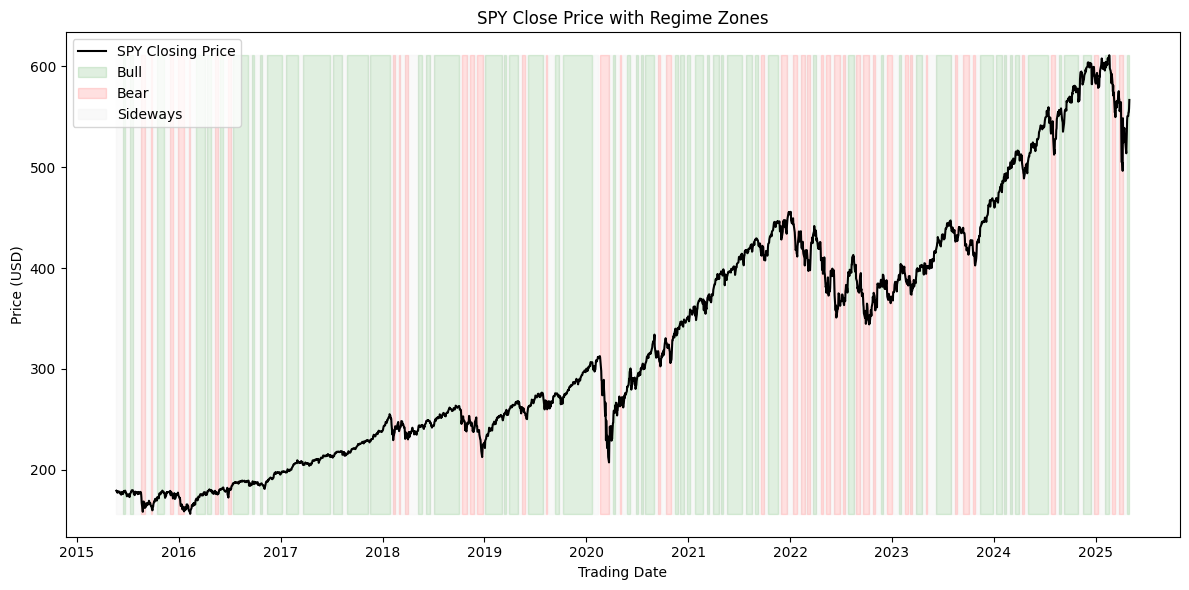

In [ ]:
import matplotlib.pyplot as plt

# Match the length of inferred regime labels with the price data
viz_data = processed_data.tail(len(inferred_regimes)).copy()
viz_data['Market_Regime'] = inferred_regimes

# Set up the plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(viz_data.index, viz_data['close'], color='black', label='SPY Closing Price')

# Define shading colors per regime
regime_palette = {'Bull': 'green', 'Bear': 'red', 'Sideways': 'lightgray'}

# Highlight each regime as a background band
for state, color in regime_palette.items():
    highlight = viz_data['Market_Regime'] == state
    ax.fill_between(viz_data.index,
                    viz_data['close'].min(),
                    viz_data['close'].max(),
                    where=highlight,
                    color=color,
                    alpha=0.12,
                    label=state)

# Add plot details
ax.set_title("SPY Close Price with Regime Zones")
ax.set_xlabel("Trading Date")
ax.set_ylabel("Price (USD)")
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig("regime_plot_with_background.png")
plt.show()


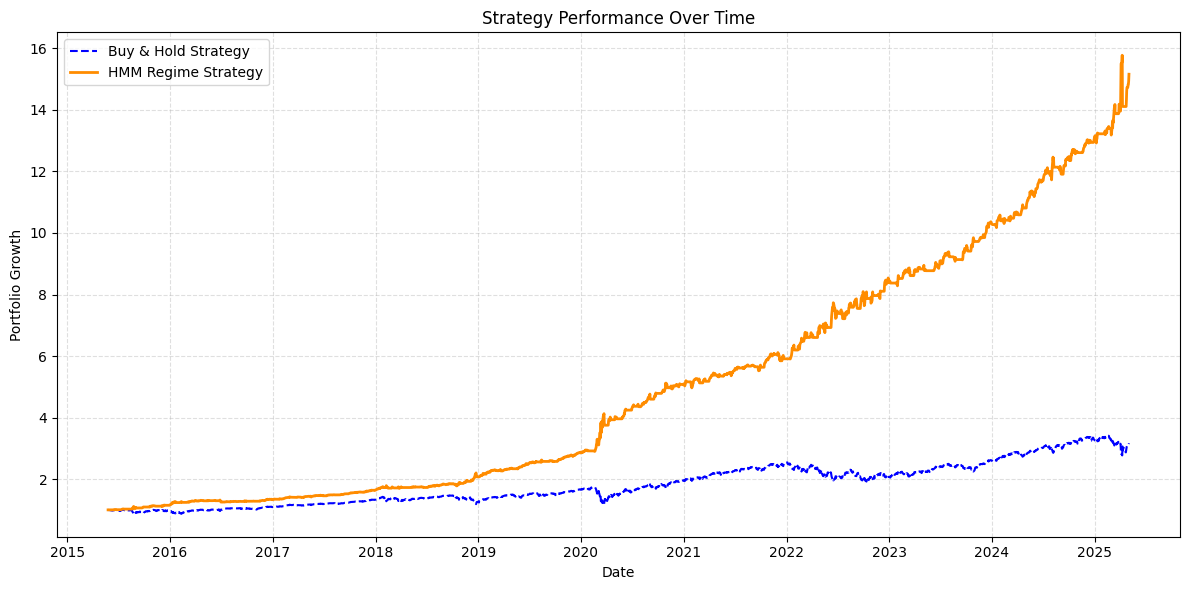

In [ ]:
# Duplicate data for strategy analysis
returns_data = aligned_data.copy()

# Calculate basic returns
returns_data['Pct_Change'] = returns_data['close'].pct_change()

# Assign trading position based on regime logic
regime_map = {'Bull': 1, 'Bear': -1, 'Sideways': 0}
returns_data['Signal'] = returns_data['Regime'].map(regime_map).shift(1).fillna(0)

# Compute strategy returns and apply trading frictions
returns_data['Gross_Strategy'] = returns_data['Signal'] * returns_data['Pct_Change']
returns_data['Shifted'] = returns_data['Signal'] != returns_data['Signal'].shift(1)
returns_data['Txn_Cost'] = 0.0005 * returns_data['Shifted'].astype(float) + 0.001 * returns_data['Gross_Strategy'].abs()
returns_data['Net_Returns'] = returns_data['Gross_Strategy'] - returns_data['Txn_Cost']

# Cumulative performance
curve_bh = (1 + returns_data['Pct_Change']).cumprod()
curve_hmm = (1 + returns_data['Net_Returns']).cumprod()

# Plot performance
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(returns_data.index, curve_bh, linestyle='dashed', color='blue', label='Buy & Hold Strategy')
ax.plot(returns_data.index, curve_hmm, color='darkorange', linewidth=2, label='HMM Regime Strategy')

# Style and labels
ax.set_title("Strategy Performance Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Growth")
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='best')
plt.tight_layout()
plt.savefig("hmm_equity_comparison_plot.png")
plt.show()


In [ ]:

import copy

def stress_test(processed_data, regime_labels, states, transition_prob, emission_prob):
    """
    Stress Testing:
    - Extend a crisis period by repeating worst 10 days
    - Amplify volatility by 50%
    - Re-run HMM and evaluate performance
    """
    stressed_data = copy.deepcopy(processed_data)

    #  Identify 10 worst days (lowest returns)
    stressed_data['Daily_Return'] = stressed_data['close'].pct_change()
    worst_10_days = stressed_data['Daily_Return'].nsmallest(10)

    print("Worst 10 Days Identified for Stress Testing:\n", worst_10_days)

    #  Repeat the worst 10-day sequence
    repeat_returns = worst_10_days.values
    repeat_returns = np.tile(repeat_returns, 1)  # Repeat once (10 days)


    last_price = stressed_data['close'].iloc[-1]
    synthetic_prices = [last_price]
    for r in repeat_returns:
        new_price = synthetic_prices[-1] * (1 + r)
        synthetic_prices.append(new_price)

    synthetic_prices = synthetic_prices[1:]
    stressed_data.index = pd.to_datetime(stressed_data.index)

    synthetic_dates = pd.date_range(start=stressed_data.index[-1] + pd.Timedelta(days=1), periods=len(synthetic_prices), freq='B')

    stress_df = pd.DataFrame({
        'close': synthetic_prices
    }, index=synthetic_dates)

    stress_df['close'] *= (1 + np.random.normal(0, 0.01 * 1.5, size=len(stress_df)))  # 1.5x volatility

    stressed_full = pd.concat([stressed_data, stress_df])

    # Recalculate features on stressed data
    stressed_full['Return'] = stressed_full['close'].pct_change() * 100
    stressed_full['Volatility'] = stressed_full['Return'].rolling(window=5).std() * np.sqrt(252)

    def compute_rsi(prices, window=14):
        delta = prices.diff()
        gain = delta.where(delta > 0, 0)
        loss = -delta.where(delta < 0, 0)
        avg_gain = gain.rolling(window=window).mean()
        avg_loss = loss.rolling(window=window).mean()
        rs = avg_gain / avg_loss
        rsi_values = 100 - (100 / (1 + rs))
        return rsi_values

    stressed_full['RSI'] = compute_rsi(stressed_full['close'])

    # Bin features again
    return_tertiles = np.nanpercentile(stressed_full['Return'].dropna(), [33.33, 66.66])
    vol_median = stressed_full['Volatility'].median()

    stressed_full['Return_Bin'] = stressed_full['Return'].apply(
        lambda x: 'Low' if x <= return_tertiles[0] else ('Medium' if x <= return_tertiles[1] else 'High'))
    stressed_full['Vol_Bin'] = stressed_full['Volatility'].apply(lambda x: 'Low' if x <= vol_median else 'High')

    stressed_full['RSI_Signal'] = stressed_full['RSI'].apply(
        lambda x: 'Overbought' if x > 70 else ('Oversold' if x < 30 else 'Neutral')
    )

    stressed_full = stressed_full.dropna()

    # Build observations again
    stressed_observations = []
    for idx, row in stressed_full.iterrows():
        obs = {
            'Return_Bin': row['Return_Bin'],
            'Vol_Bin': row['Vol_Bin'],
            'RSI_Signal': row['RSI_Signal']
        }
        stressed_observations.append(obs)

    # Run Viterbi again
    stressed_regime_labels = constrained_viterbi(stressed_observations, states, transition_prob, emission_prob)

    # Evaluate stressed performance
    stressed_results = evaluate_strategy(stressed_regime_labels, stressed_full['close'])

    print("\n Stress Testing Results:")
    print(stressed_results)

    return stressed_results, stressed_regime_labels



#  To run:
# stressed_results = stress_test(processed_data, regime_labels, states, transition_prob, emission_prob)


In [ ]:
stressed_results, stressed_regime_labels = stress_test(processed_data, regime_labels, states, transition_prob, emission_prob)
# After stress test
print("First 20 regime labels after stress:", stressed_regime_labels[:20])


Worst 10 Days Identified for Stress Testing:
 Date
2020-03-16 00:00:00-04:00   -0.109424
2020-03-12 00:00:00-04:00   -0.095677
2020-03-09 00:00:00-04:00   -0.078095
2025-04-04 00:00:00-04:00   -0.058543
2020-06-11 00:00:00-04:00   -0.057649
2020-03-18 00:00:00-04:00   -0.050633
2025-04-03 00:00:00-04:00   -0.049281
2020-03-11 00:00:00-04:00   -0.048748
2020-04-01 00:00:00-04:00   -0.045005
2020-02-27 00:00:00-05:00   -0.044912
Name: Daily_Return, dtype: float64

 Stress Testing Results:
{'Sharpe': {'BuyHold': np.float64(0.731), 'HMM': np.float64(1.983)}, 'MaxDD': {'BuyHold': 33.72, 'HMM': 10.56}}
First 20 regime labels after stress: ['Sideways', 'Bear', 'Bear', 'Sideways', 'Bull', 'Bull', 'Bull', 'Bull', 'Bull', 'Sideways', 'Sideways', 'Sideways', 'Sideways', 'Sideways', 'Sideways', 'Sideways', 'Sideways', 'Sideways', 'Sideways', 'Sideways']


In [ ]:
print("Sample stressed regime labels (first 20):")
for i, label in enumerate(stressed_regime_labels[:20]):
    print(f"Day {i+1}: {label}")


Sample stressed regime labels (first 20):
Day 1: Sideways
Day 2: Bear
Day 3: Bear
Day 4: Sideways
Day 5: Bull
Day 6: Bull
Day 7: Bull
Day 8: Bull
Day 9: Bull
Day 10: Sideways
Day 11: Sideways
Day 12: Sideways
Day 13: Sideways
Day 14: Sideways
Day 15: Sideways
Day 16: Sideways
Day 17: Sideways
Day 18: Sideways
Day 19: Sideways
Day 20: Sideways


**The model detected initial Bear pressure, transitioned through Sideways, and returned to Bull, showing realistic recovery behavior under stress.**

## Submission Checklist
- [ ] Completed all TODOs in code cells
- [ ] Hand-drawn state diagram (photo)
- [ ] 2-page PDF report with:
  - Parameter justifications
  - Backtest results
  - Stress test analysis
- [ ] 2-minute video explanation

### Grading Rubric
| Component               | Points |
|-------------------------|--------|
| Data Preprocessing      | 20     |
| HMM Parameter Design    | 30     |
| Viterbi Implementation  | 25     |
| Backtesting             | 15     |
| Stress Testing          | 10     |